In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# Load all processed data
features = pd.read_csv("../data/processed/customer_features.csv")
segments = pd.read_csv("../data/processed/customer_segments.csv")[
    ['customer_id', 'cluster', 'segment', 'spend_tier']
]
churn = pd.read_csv("../data/processed/customer_churn_scores.csv")[
    ['customer_id', 'returned', 'churned',
     'return_probability', 'churn_risk_tier']
]

print(f"Features:  {features.shape}")
print(f"Segments:  {segments.shape}")
print(f"Churn:     {churn.shape}")

Features:  (96478, 26)
Segments:  (96478, 4)
Churn:     (84893, 5)


In [2]:
import duckdb

con = duckdb.connect("../data/ecommerce.db", read_only=True)

# Pull all delivered transactions per unique customer
transactions = con.execute("""
    SELECT
        c.customer_unique_id,
        o.purchased_at::DATE    AS order_date,
        SUM(oi.price)           AS order_value
    FROM orders_clean o
    JOIN customers c         USING (customer_id)
    JOIN order_items_clean oi USING (order_id)
    WHERE o.order_status = 'delivered'
    GROUP BY
        c.customer_unique_id,
        o.purchased_at::DATE
    ORDER BY
        c.customer_unique_id,
        o.purchased_at::DATE
""").df()

# Also pull customer_id → customer_unique_id bridge
id_bridge = con.execute("""
    SELECT DISTINCT
        c.customer_unique_id,
        o.customer_id
    FROM orders_clean o
    JOIN customers c USING (customer_id)
    WHERE o.order_status = 'delivered'
""").df()

con.close()

print(f"Transactions shape: {transactions.shape}")
print(f"Unique customers:   {transactions['customer_unique_id'].nunique():,}")
print(f"Date range: {transactions['order_date'].min()} → {transactions['order_date'].max()}")
print(transactions.head(5))

Transactions shape: (95588, 3)
Unique customers:   93,358
Date range: 2016-09-15 00:00:00 → 2018-08-29 00:00:00
                 customer_unique_id order_date  order_value
0  0000366f3b9a7992bf8c76cfdf3221e2 2018-05-10       129.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f 2018-05-07        18.90
2  0000f46a3911fa3c0805444483337064 2017-03-10        69.00
3  0000f6ccb0745a6a4b88665a16c9f078 2017-10-12        25.99
4  0004aac84e0df4da2b147fca70cf8255 2017-11-14       180.00


In [3]:
from lifetimes.utils import summary_data_from_transaction_data

OBSERVATION_PERIOD_END = pd.Timestamp("2018-10-18")

# Convert order_date to datetime
transactions['order_date'] = pd.to_datetime(transactions['order_date'])

# Build summary data
# frequency = number of REPEAT purchases (first purchase excluded)
# recency   = time between first and last purchase (in days)
# T         = time between first purchase and observation end (in days)
# monetary_value = mean transaction value (EXCLUDING first transaction)

summary = summary_data_from_transaction_data(
    transactions,
    customer_id_col    = 'customer_unique_id',
    datetime_col       = 'order_date',
    monetary_value_col = 'order_value',
    observation_period_end = OBSERVATION_PERIOD_END,
    freq = 'D',   # daily frequency
)

print(f"Summary data shape: {summary.shape}")
print(f"\nColumns: {summary.columns.tolist()}")
print(f"\nSample:")
print(summary.head(5))
print(f"\nDescriptive stats:")
print(summary.describe().round(2))

Summary data shape: (93358, 4)

Columns: ['frequency', 'recency', 'T', 'monetary_value']

Sample:
                                  frequency  recency      T  monetary_value
customer_unique_id                                                         
0000366f3b9a7992bf8c76cfdf3221e2        0.0      0.0  161.0             0.0
0000b849f77a49e4a4ce2b2a4ca5be3f        0.0      0.0  164.0             0.0
0000f46a3911fa3c0805444483337064        0.0      0.0  587.0             0.0
0000f6ccb0745a6a4b88665a16c9f078        0.0      0.0  371.0             0.0
0004aac84e0df4da2b147fca70cf8255        0.0      0.0  338.0             0.0

Descriptive stats:
       frequency   recency         T  monetary_value
count   93358.00  93358.00  93358.00        93358.00
mean        0.02      2.65    290.12            2.76
std         0.18     25.01    153.10           28.76
min         0.00      0.00     50.00            0.00
25%         0.00      0.00    166.00            0.00
50%         0.00      0.00    27

In [4]:
print("\nFrequency distribution (repeat purchases):")
freq_dist = summary['frequency'].value_counts().sort_index().head(10)
for freq, count in freq_dist.items():
    pct = count / len(summary) * 100
    print(f"  {freq} repeat purchases: {count:>8,} customers ({pct:.1f}%)")

print(f"\nCustomers with 0 repeat purchases: "
      f"{(summary['frequency']==0).sum():,} "
      f"({(summary['frequency']==0).mean():.1%})")
print(f"Customers with 1+ repeat purchases: "
      f"{(summary['frequency']>0).sum():,} "
      f"({(summary['frequency']>0).mean():.1%})")


Frequency distribution (repeat purchases):
  0.0 repeat purchases:   91,343 customers (97.8%)
  1.0 repeat purchases:    1,864 customers (2.0%)
  2.0 repeat purchases:      120 customers (0.1%)
  3.0 repeat purchases:       17 customers (0.0%)
  4.0 repeat purchases:        6 customers (0.0%)
  5.0 repeat purchases:        5 customers (0.0%)
  6.0 repeat purchases:        2 customers (0.0%)
  14.0 repeat purchases:        1 customers (0.0%)

Customers with 0 repeat purchases: 91,343 (97.8%)
Customers with 1+ repeat purchases: 2,015 (2.2%)


In [5]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.001)

print("Fitting BG/NBD model...")
bgf.fit(
    frequency       = summary['frequency'],
    recency         = summary['recency'],
    T               = summary['T'],
)

print(f"\nBG/NBD model fitted successfully.")
print(f"\nModel parameters:")
print(f"  r (transaction rate shape):  {bgf.params_['r']:.4f}")
print(f"  alpha (transaction rate scale): {bgf.params_['alpha']:.4f}")
print(f"  a (dropout shape):           {bgf.params_['a']:.4f}")
print(f"  b (dropout scale):           {bgf.params_['b']:.4f}")

Fitting BG/NBD model...

BG/NBD model fitted successfully.

Model parameters:
  r (transaction rate shape):  0.0120
  alpha (transaction rate scale): 49.3009
  a (dropout shape):           0.4272
  b (dropout scale):           0.0594


In [6]:
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

# Split into calibration (first 75%) and holdout (last 25%) periods
calibration_end = pd.Timestamp("2018-01-01")

from lifetimes.utils import calibration_and_holdout_data

summary_cal_holdout = calibration_and_holdout_data(
    transactions,
    customer_id_col    = 'customer_unique_id',
    datetime_col       = 'order_date',
    monetary_value_col = 'order_value',
    calibration_period_end = calibration_end,
    observation_period_end = OBSERVATION_PERIOD_END,
    freq = 'D',
)

print(f"Calibration/holdout shape: {summary_cal_holdout.shape}")
print(summary_cal_holdout.head(3))

# Fit on calibration period only
bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(
    frequency = summary_cal_holdout['frequency_cal'],
    recency   = summary_cal_holdout['recency_cal'],
    T         = summary_cal_holdout['T_cal'],
)

print(f"\nCalibration model params:")
for k, v in bgf_cal.params_.items():
    print(f"  {k}: {v:.4f}")

Calibration/holdout shape: (42466, 7)
                                  frequency_cal  recency_cal  T_cal  \
customer_unique_id                                                    
0000f46a3911fa3c0805444483337064            0.0          0.0  297.0   
0000f6ccb0745a6a4b88665a16c9f078            0.0          0.0   81.0   
0004aac84e0df4da2b147fca70cf8255            0.0          0.0   48.0   

                                  monetary_value_cal  frequency_holdout  \
customer_unique_id                                                        
0000f46a3911fa3c0805444483337064                 0.0                0.0   
0000f6ccb0745a6a4b88665a16c9f078                 0.0                0.0   
0004aac84e0df4da2b147fca70cf8255                 0.0                0.0   

                                  monetary_value_holdout  duration_holdout  
customer_unique_id                                                          
0000f46a3911fa3c0805444483337064                     0.0             290.0  

In [7]:
# Predict number of purchases in next 12 months (365 days)
PREDICTION_HORIZON = 365

summary['predicted_purchases_12m'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    t          = PREDICTION_HORIZON,
    frequency  = summary['frequency'],
    recency    = summary['recency'],
    T          = summary['T'],
)

# Probability customer is still alive (not permanently churned)
summary['prob_alive'] = bgf.conditional_probability_alive(
    frequency = summary['frequency'],
    recency   = summary['recency'],
    T         = summary['T'],
)

print("Predicted purchases summary:")
print(summary[['frequency', 'recency', 'T',
               'predicted_purchases_12m',
               'prob_alive']].describe().round(3))

print(f"\nTop 10 customers by predicted future purchases:")
print(
    summary.sort_values('predicted_purchases_12m', ascending=False)
    [['frequency', 'recency', 'T',
      'predicted_purchases_12m', 'prob_alive']]
    .head(10)
    .round(3)
    .to_string()
)

Predicted purchases summary:
       frequency    recency          T  predicted_purchases_12m  prob_alive
count  93358.000  93358.000  93358.000                93358.000   93358.000
mean       0.024      2.645    290.124                    0.012       0.980
std        0.177     25.007    153.103                    0.042       0.135
min        0.000      0.000     50.000                    0.004       0.008
25%        0.000      0.000    166.000                    0.007       1.000
50%        0.000      0.000    271.000                    0.010       1.000
75%        0.000      0.000    400.000                    0.013       1.000
max       14.000    633.000    763.000                    7.230       1.000

Top 10 customers by predicted future purchases:
                                  frequency  recency      T  predicted_purchases_12m  prob_alive
customer_unique_id                                                                              
8d50f5eadf50201ccdcedfb9e2ac8455       14.0 

In [8]:
from lifetimes import GammaGammaFitter

# Filter: must have at least 1 repeat purchase and positive monetary value
returning_customers = summary[
    (summary['frequency'] > 0) &
    (summary['monetary_value'] > 0)
].copy()

print(f"Customers eligible for Gamma-Gamma: {len(returning_customers):,}")
print(f"(requires frequency > 0 and monetary_value > 0)")
print(f"\nMonetary value stats for eligible customers:")
print(returning_customers['monetary_value'].describe().round(2))

Customers eligible for Gamma-Gamma: 2,015
(requires frequency > 0 and monetary_value > 0)

Monetary value stats for eligible customers:
count    2015.00
mean      127.66
std       149.61
min         3.85
25%        48.25
50%        89.90
75%       149.90
max      2040.00
Name: monetary_value, dtype: float64


In [9]:
corr = returning_customers[['frequency', 'monetary_value']].corr()
print(f"\nCorrelation between frequency and monetary value:")
print(corr.round(4))
print(f"\nCorrelation value: {corr.loc['frequency','monetary_value']:.4f}")
print("(Should be low, ideally < 0.3 — Gamma-Gamma assumes independence)")


Correlation between frequency and monetary value:
                frequency  monetary_value
frequency          1.0000         -0.0003
monetary_value    -0.0003          1.0000

Correlation value: -0.0003
(Should be low, ideally < 0.3 — Gamma-Gamma assumes independence)


In [10]:
ggf = GammaGammaFitter(penalizer_coef=0.001)

print("Fitting Gamma-Gamma model...")
ggf.fit(
    frequency      = returning_customers['frequency'],
    monetary_value = returning_customers['monetary_value'],
)

print(f"\nGamma-Gamma model fitted successfully.")
print(f"\nModel parameters:")
print(f"  p (shape of individual mean):  {ggf.params_['p']:.4f}")
print(f"  q (shape of gamma mixing):     {ggf.params_['q']:.4f}")
print(f"  v (scale of gamma mixing):     {ggf.params_['v']:.4f}")

Fitting Gamma-Gamma model...

Gamma-Gamma model fitted successfully.

Model parameters:
  p (shape of individual mean):  8.4697
  q (shape of gamma mixing):     1.2245
  v (scale of gamma mixing):     8.1080


In [11]:
returning_customers['expected_avg_value'] = ggf.conditional_expected_average_profit(
    frequency      = returning_customers['frequency'],
    monetary_value = returning_customers['monetary_value'],
)

print("\nExpected avg transaction value vs actual:")
comparison = returning_customers[['monetary_value', 'expected_avg_value']].describe().round(2)
print(comparison)

# Gamma-Gamma should slightly shrink towards the mean (regularisation)
actual_mean   = returning_customers['monetary_value'].mean()
expected_mean = returning_customers['expected_avg_value'].mean()
print(f"\nActual mean:   BRL {actual_mean:.2f}")
print(f"Expected mean: BRL {expected_mean:.2f}")
print(f"Shrinkage:     {((actual_mean - expected_mean)/actual_mean*100):.2f}%")


Expected avg transaction value vs actual:
       monetary_value  expected_avg_value
count         2015.00             2015.00
mean           127.66              132.08
std            149.61              145.85
min              3.85               11.65
25%             48.25               54.56
50%             89.90               95.48
75%            149.90              153.93
max           2040.00             1995.23

Actual mean:   BRL 127.66
Expected mean: BRL 132.08
Shrinkage:     -3.46%


In [12]:
# Monthly discount rate — assume 12% annual = 1% monthly
DISCOUNT_RATE   = 0.01
TIME_MONTHS     = 12

# CLV only for returning customers (freq > 0)
returning_customers['clv_12m'] = ggf.customer_lifetime_value(
    transaction_prediction_model = bgf,
    frequency      = returning_customers['frequency'],
    recency        = returning_customers['recency'],
    T              = returning_customers['T'],
    monetary_value = returning_customers['monetary_value'],
    time           = TIME_MONTHS,
    discount_rate  = DISCOUNT_RATE,
    freq           = 'D',
)

print(f"CLV computed for {len(returning_customers):,} returning customers")
print(f"\nCLV distribution:")
print(returning_customers['clv_12m'].describe().round(2))
print(f"\nTop 10 customers by 12-month CLV:")
print(
    returning_customers.sort_values('clv_12m', ascending=False)
    [['frequency', 'monetary_value', 'prob_alive',
      'predicted_purchases_12m', 'clv_12m']]
    .head(10)
    .round(2)
    .to_string()
)

CLV computed for 2,015 returning customers

CLV distribution:
count    2015.00
mean       11.88
std        38.35
min         0.09
25%         1.66
50%         3.59
75%         7.67
max       671.97
Name: clv_12m, dtype: float64

Top 10 customers by 12-month CLV:
                                  frequency  monetary_value  prob_alive  predicted_purchases_12m  clv_12m
customer_unique_id                                                                                       
fe81bb32c243a86b2f86fbf053fe6140        4.0          369.85        0.64                     1.96   671.97
4facc2e6fbc2bffab2fea92d2b4aa7e4        3.0          512.63        0.76                     1.37   650.44
397b44d5bb99eabf54ea9c2b41ebb905        3.0          460.00        0.54                     1.48   633.48
297ec5afd18366f5ba27520cc4954151        2.0          681.22        0.34                     0.68   428.75
8d50f5eadf50201ccdcedfb9e2ac8455       14.0           48.20        0.86                     7.23   32

In [13]:
# One-time buyers: CLV = monetary_value * prob_alive * 0.3
# (conservative estimate — low probability of return)
one_time_buyers = summary[summary['frequency'] == 0].copy()

one_time_buyers['clv_12m'] = (
    one_time_buyers['monetary_value'] *
    one_time_buyers['prob_alive'] *
    0.3
)

one_time_buyers['expected_avg_value'] = one_time_buyers['monetary_value']

print(f"One-time buyer CLV (fallback estimate):")
print(one_time_buyers['clv_12m'].describe().round(2))

One-time buyer CLV (fallback estimate):
count    91343.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: clv_12m, dtype: float64


In [14]:
# Merge returning and one-time buyer CLV
clv_returning = returning_customers[['clv_12m', 'prob_alive',
                                     'predicted_purchases_12m',
                                     'expected_avg_value']].copy()

clv_onetimers = one_time_buyers[['clv_12m', 'prob_alive',
                                  'predicted_purchases_12m',
                                  'expected_avg_value']].copy()

clv_all = pd.concat([clv_returning, clv_onetimers])

# Merge back into summary
summary = summary.merge(
    clv_all[['clv_12m', 'expected_avg_value']],
    left_index=True,
    right_index=True,
    how='left'
)

# Fill any remaining nulls
summary['clv_12m']            = summary['clv_12m'].fillna(0)
summary['expected_avg_value'] = summary['expected_avg_value'].fillna(
    summary['monetary_value']
)

print(f"\nFull CLV summary ({len(summary):,} customers):")
print(summary[['frequency', 'monetary_value',
               'predicted_purchases_12m',
               'clv_12m']].describe().round(2))


Full CLV summary (93,358 customers):
       frequency  monetary_value  predicted_purchases_12m   clv_12m
count   93358.00        93358.00                 93358.00  93358.00
mean        0.02            2.76                     0.01      0.26
std         0.18           28.76                     0.04      5.89
min         0.00            0.00                     0.00      0.00
25%         0.00            0.00                     0.01      0.00
50%         0.00            0.00                     0.01      0.00
75%         0.00            0.00                     0.01      0.00
max        14.00         2040.00                     7.23    671.97


In [16]:
# CLV tiers — use fixed thresholds instead of qcut
# qcut fails when >75% of values are identical (all zeros from one-time buyers)

print(f"CLV value distribution:")
print(f"  Zero CLV customers:     {(summary['clv_12m'] == 0).sum():,} "
      f"({(summary['clv_12m'] == 0).mean():.1%})")
print(f"  Non-zero CLV customers: {(summary['clv_12m'] > 0).sum():,} "
      f"({(summary['clv_12m'] > 0).mean():.1%})")
print(f"\nNon-zero CLV percentiles:")
nonzero = summary[summary['clv_12m'] > 0]['clv_12m']
print(nonzero.describe().round(2))

# Fixed threshold tiers based on actual distribution
p33 = nonzero.quantile(0.33)
p66 = nonzero.quantile(0.66)

print(f"\nTier thresholds:")
print(f"  Bronze:   CLV = 0")
print(f"  Silver:   0 < CLV <= {p33:.2f}")
print(f"  Gold:     {p33:.2f} < CLV <= {p66:.2f}")
print(f"  Platinum: CLV > {p66:.2f}")

def assign_clv_tier(clv):
    if clv == 0:
        return 'Bronze'
    elif clv <= p33:
        return 'Silver'
    elif clv <= p66:
        return 'Gold'
    else:
        return 'Platinum'

summary['clv_tier'] = summary['clv_12m'].apply(assign_clv_tier)

print(f"\nCLV tier distribution:")
tier_counts = summary['clv_tier'].value_counts()
for tier in ['Bronze', 'Silver', 'Gold', 'Platinum']:
    count = tier_counts.get(tier, 0)
    pct   = count / len(summary) * 100
    avg   = summary.loc[summary['clv_tier'] == tier, 'clv_12m'].mean()
    print(f"  {tier:<10} {count:>8,} customers ({pct:.1f}%) | avg CLV: BRL {avg:.2f}")

CLV value distribution:
  Zero CLV customers:     91,343 (97.8%)
  Non-zero CLV customers: 2,015 (2.2%)

Non-zero CLV percentiles:
count    2015.00
mean       11.88
std        38.35
min         0.09
25%         1.66
50%         3.59
75%         7.67
max       671.97
Name: clv_12m, dtype: float64

Tier thresholds:
  Bronze:   CLV = 0
  Silver:   0 < CLV <= 2.14
  Gold:     2.14 < CLV <= 5.56
  Platinum: CLV > 5.56

CLV tier distribution:
  Bronze       91,343 customers (97.8%) | avg CLV: BRL 0.00
  Silver          665 customers (0.7%) | avg CLV: BRL 1.15
  Gold            665 customers (0.7%) | avg CLV: BRL 3.63
  Platinum        685 customers (0.7%) | avg CLV: BRL 30.30


In [17]:
print("\nCLV tier summary table:")
tier_dist = summary.groupby('clv_tier').agg(
    customers     = ('clv_12m', 'count'),
    avg_clv       = ('clv_12m', 'mean'),
    total_clv     = ('clv_12m', 'sum'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary  = ('monetary_value', 'mean'),
).round(2)
tier_dist['clv_share_%'] = (
    tier_dist['total_clv'] / tier_dist['total_clv'].sum() * 100
).round(1)

# Sort by avg CLV
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
tier_dist  = tier_dist.reindex(tier_order)
print(tier_dist.to_string())

# Pareto check
print(f"\nPareto analysis:")
sorted_clv        = summary['clv_12m'].sort_values(ascending=False)
top_20_pct_idx    = int(len(sorted_clv) * 0.20)
top_20_clv_share  = sorted_clv.iloc[:top_20_pct_idx].sum() / sorted_clv.sum() * 100
print(f"  Top 20% of customers drive {top_20_clv_share:.1f}% of total CLV")


CLV tier summary table:
          customers  avg_clv  total_clv  avg_frequency  avg_monetary  clv_share_%
clv_tier                                                                         
Bronze        91343     0.00       0.00           0.00          0.00          0.0
Silver          665     1.15     766.02           1.00         55.19          3.2
Gold            665     3.63    2415.49           1.01        100.23         10.1
Platinum        685    30.30   20757.38           1.30        224.64         86.7

Pareto analysis:
  Top 20% of customers drive 100.0% of total CLV


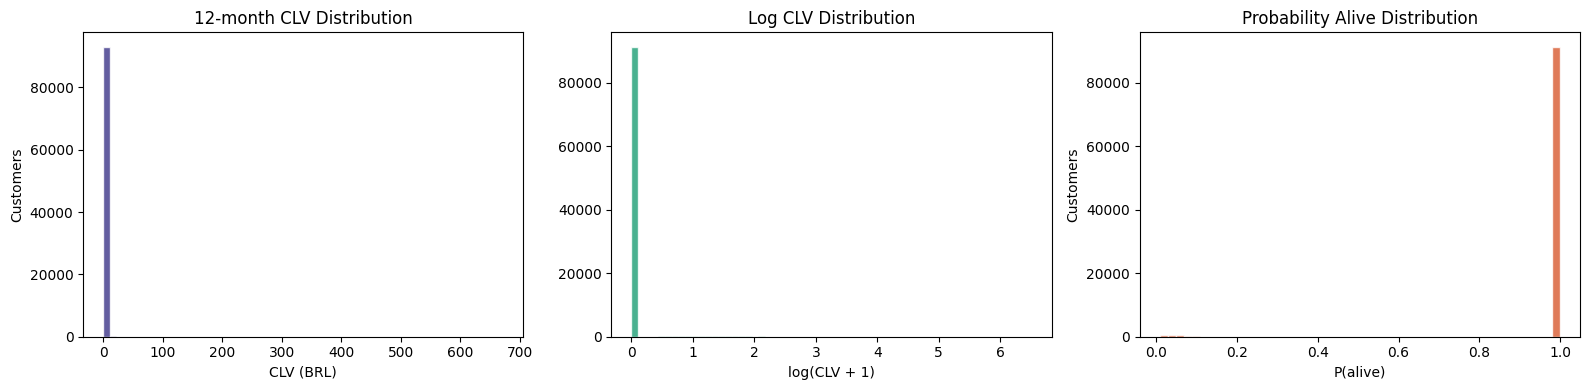

Saved: charts/clv_distributions.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw CLV histogram
axes[0].hist(summary['clv_12m'], bins=60, color='#3C3489', alpha=0.8, edgecolor='white')
axes[0].set_title("12-month CLV Distribution")
axes[0].set_xlabel("CLV (BRL)")
axes[0].set_ylabel("Customers")

# Log CLV histogram
axes[1].hist(
    np.log1p(summary['clv_12m']),
    bins=60, color='#1D9E75', alpha=0.8, edgecolor='white'
)
axes[1].set_title("Log CLV Distribution")
axes[1].set_xlabel("log(CLV + 1)")

# Prob alive distribution
axes[2].hist(summary['prob_alive'], bins=50, color='#D85A30', alpha=0.8, edgecolor='white')
axes[2].set_title("Probability Alive Distribution")
axes[2].set_xlabel("P(alive)")
axes[2].set_ylabel("Customers")

plt.tight_layout()
plt.savefig("../charts/clv_distributions.png", dpi=150)
plt.show()
print("Saved: charts/clv_distributions.png")

In [19]:
# Reset index to get customer_unique_id as a column
summary_reset = summary.reset_index()
summary_reset.rename(columns={'index': 'customer_unique_id'}, inplace=True)

# Handle case where index is already named customer_unique_id
if 'customer_unique_id' not in summary_reset.columns:
    summary_reset = summary.copy()
    summary_reset.index.name = 'customer_unique_id'
    summary_reset = summary_reset.reset_index()

print(f"Summary columns: {summary_reset.columns.tolist()}")
print(f"id_bridge shape: {id_bridge.shape}")

# Keep most recent customer_id per unique customer
id_bridge_dedup = (
    id_bridge
    .drop_duplicates(subset='customer_unique_id', keep='last')
)

# Join CLV to customer_id
clv_with_ids = summary_reset.merge(
    id_bridge_dedup,
    on='customer_unique_id',
    how='left'
)

print(f"CLV with IDs shape: {clv_with_ids.shape}")
print(f"Null customer_ids: {clv_with_ids['customer_id'].isnull().sum()}")

# Build final CLV table
clv_final = clv_with_ids[[
    'customer_id',
    'customer_unique_id',
    'frequency',
    'recency',
    'T',
    'monetary_value',
    'predicted_purchases_12m',
    'prob_alive',
    'clv_12m',
    'expected_avg_value',
    'clv_tier',
]].copy()

# Drop rows with no customer_id match
clv_final = clv_final.dropna(subset=['customer_id']).reset_index(drop=True)

print(f"\nFinal CLV table shape: {clv_final.shape}")
print(clv_final.head(5).to_string())

Summary columns: ['customer_unique_id', 'frequency', 'recency', 'T', 'monetary_value', 'predicted_purchases_12m', 'prob_alive', 'clv_12m', 'expected_avg_value', 'clv_tier']
id_bridge shape: (96478, 2)
CLV with IDs shape: (93358, 11)
Null customer_ids: 0

Final CLV table shape: (93358, 11)
                        customer_id                customer_unique_id  frequency  recency      T  monetary_value  predicted_purchases_12m  prob_alive  clv_12m  expected_avg_value clv_tier
0  fadbb3709178fc513abc1b2670aa1ad2  0000366f3b9a7992bf8c76cfdf3221e2        0.0      0.0  161.0             0.0                 0.012906         1.0      0.0                 0.0   Bronze
1  4cb282e167ae9234755102258dd52ee8  0000b849f77a49e4a4ce2b2a4ca5be3f        0.0      0.0  164.0             0.0                 0.012783         1.0      0.0                 0.0   Bronze
2  9b3932a6253894a02c1df9d19004239f  0000f46a3911fa3c0805444483337064        0.0      0.0  587.0             0.0                 0.005601         

In [20]:
# Build full master CLV table
master_clv = clv_final.merge(
    segments, on='customer_id', how='left'
).merge(
    churn[['customer_id', 'returned', 'churn_risk_tier',
           'return_probability']],
    on='customer_id', how='left'
).merge(
    features[['customer_id', 'avg_review_score',
              'favourite_category', 'preferred_payment',
              'tenure_days', 'avg_delivery_delta']],
    on='customer_id', how='left'
)

print(f"Master CLV shape: {master_clv.shape}")
print(f"\nCLV by segment:")
seg_clv = master_clv.groupby('segment').agg(
    customers             = ('customer_id',     'count'),
    avg_clv               = ('clv_12m',         'mean'),
    total_clv             = ('clv_12m',         'sum'),
    avg_prob_alive        = ('prob_alive',       'mean'),
    avg_predicted_orders  = ('predicted_purchases_12m', 'mean'),
).round(2)
seg_clv['clv_share_%'] = (
    seg_clv['total_clv'] / seg_clv['total_clv'].sum() * 100
).round(1)
print(seg_clv.sort_values('avg_clv', ascending=False).to_string())

print(f"\nCLV by churn risk tier:")
risk_clv = master_clv.groupby('churn_risk_tier').agg(
    customers  = ('customer_id', 'count'),
    avg_clv    = ('clv_12m',    'mean'),
    total_clv  = ('clv_12m',   'sum'),
).round(2)
print(risk_clv.sort_values('avg_clv', ascending=False).to_string())

Master CLV shape: (93489, 22)

CLV by segment:
                   customers  avg_clv  total_clv  avg_prob_alive  avg_predicted_orders  clv_share_%
segment                                                                                            
Budget Buyers           5237     0.35    1845.57            0.98                  0.01          7.7
Mainstream Plus        24608     0.31    7590.78            0.98                  0.01         31.7
Economy Shoppers       16943     0.28    4717.44            0.98                  0.01         19.7
Mainstream Buyers      20061     0.21    4154.62            0.98                  0.01         17.4
Mid-Tier Shoppers      14203     0.21    3011.36            0.98                  0.01         12.6
Premium Buyers         12437     0.21    2619.12            0.98                  0.01         10.9

CLV by churn risk tier:
                 customers  avg_clv  total_clv
churn_risk_tier                               
Medium                 856     0.4

In [21]:
from scipy import stats

print("Kruskal-Wallis test: CLV differs across segments?")
groups = [
    master_clv.loc[master_clv['segment'] == s, 'clv_12m'].values
    for s in master_clv['segment'].dropna().unique()
]
h_stat, p_val = stats.kruskal(*groups)
print(f"  H-statistic: {h_stat:.2f}")
print(f"  p-value:     {p_val:.4e}")
print(f"  Significant: {'YES' if p_val < 0.05 else 'NO'}")

print(f"\nKruskal-Wallis test: CLV differs across churn risk tiers?")
risk_groups = [
    master_clv.loc[master_clv['churn_risk_tier'] == r, 'clv_12m'].values
    for r in master_clv['churn_risk_tier'].dropna().unique()
]
h_stat_r, p_val_r = stats.kruskal(*risk_groups)
print(f"  H-statistic: {h_stat_r:.2f}")
print(f"  p-value:     {p_val_r:.4e}")
print(f"  Significant: {'YES' if p_val_r < 0.05 else 'NO'}")

print(f"\nSpearman correlation: CLV vs churn risk:")
valid = master_clv[['clv_12m', 'return_probability']].dropna()
corr, p = stats.spearmanr(valid['clv_12m'], valid['return_probability'])
print(f"  Spearman r: {corr:.4f}")
print(f"  p-value:    {p:.4e}")
print(f"  Direction:  {'Higher CLV → higher return probability' if corr > 0 else 'Higher CLV → lower return probability'}")

Kruskal-Wallis test: CLV differs across segments?
  H-statistic: 19.35
  p-value:     1.6551e-03
  Significant: YES

Kruskal-Wallis test: CLV differs across churn risk tiers?
  H-statistic: 395.64
  p-value:     1.9456e-85
  Significant: YES

Spearman correlation: CLV vs churn risk:
  Spearman r: 0.0780
  p-value:    7.1686e-113
  Direction:  Higher CLV → higher return probability


In [24]:
import joblib
import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../data/models",    exist_ok=True)

# Save full CLV table
master_clv.to_csv("../data/processed/customer_clv.csv", index=False)
print(f"Saved: ../data/processed/customer_clv.csv ({len(master_clv):,} rows)")

# Save a minimal version for the Streamlit dashboard
clv_dashboard = master_clv[[
    'customer_id', 'clv_12m', 'clv_tier',
    'prob_alive', 'predicted_purchases_12m',
    'frequency', 'monetary_value',
    'expected_avg_value', 'segment',
    'churn_risk_tier', 'return_probability',
]].copy()
clv_dashboard.to_csv("../data/processed/customer_clv_dashboard.csv", index=False)
print(f"Saved: ../data/processed/customer_clv_dashboard.csv")

# Save fitted models
joblib.dump(bgf, "../data/models/bgnbd_model.pkl")
joblib.dump(ggf, "../data/models/gamma_gamma_model.pkl")
print("Saved: ../data/models/bgnbd_model.pkl")
print("Saved: ../data/models/gamma_gamma_model.pkl")

# Reload and verify
check = pd.read_csv("../data/processed/customer_clv.csv")
print(f"\nReload check: {check.shape}")
print(check[['customer_id', 'clv_12m', 'clv_tier',
             'prob_alive', 'predicted_purchases_12m']].describe().round(2))

Saved: ../data/processed/customer_clv.csv (93,489 rows)
Saved: ../data/processed/customer_clv_dashboard.csv
Saved: ../data/models/bgnbd_model.pkl
Saved: ../data/models/gamma_gamma_model.pkl

Reload check: (93489, 22)
        clv_12m  prob_alive  predicted_purchases_12m
count  93489.00    93489.00                 93489.00
mean       0.26        0.98                     0.01
std        5.89        0.13                     0.04
min        0.00        0.01                     0.00
25%        0.00        1.00                     0.01
50%        0.00        1.00                     0.01
75%        0.00        1.00                     0.01
max      671.97        1.00                     7.23
